##  Прогнозирование геомагнитных бурь

**Цель: Разработка системы мониторинга и прогнозирования уровня геомагнитной угрозы**

**Бизнес-задача:** Операторы спутниковых группировок (Starlink, OneWeb) несут убытки из-за внезапных геомагнитных бурь. 

Необходима система, которая прогнозирует уровень угрозы и даёт рекомендации для принятия защитных мер.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

**Загрузка и анализ данных**

In [4]:
df_kaggle = pd.read_csv(r'C:\Users\user\Desktop\MyProjects\geomagnetic-forecast\data\kaggle\processed\kaggle_ready.csv')
print(f" Загружено Kaggle данных: {len(df_kaggle)} событий")
print(f"\nСтруктура данных:")
print(df_kaggle.info())
print(f"\nПервые 5 строк:")
print(df_kaggle.head())


 Загружено Kaggle данных: 1000 событий

Структура данных:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   kp_index      1000 non-null   float64
 1   wind_speed    1000 non-null   float64
 2   wind_density  1000 non-null   float64
 3   threat_level  1000 non-null   int64  
dtypes: float64(3), int64(1)
memory usage: 31.4 KB
None

Первые 5 строк:
   kp_index  wind_speed  wind_density  threat_level
0       4.0      558.43         12.62             2
1       0.0      723.17          6.26             1
2       0.0      626.27          7.81             1
3       2.0      498.49          5.94             1
4       0.0      505.02         18.03             1


**Визуализация распределения классов**

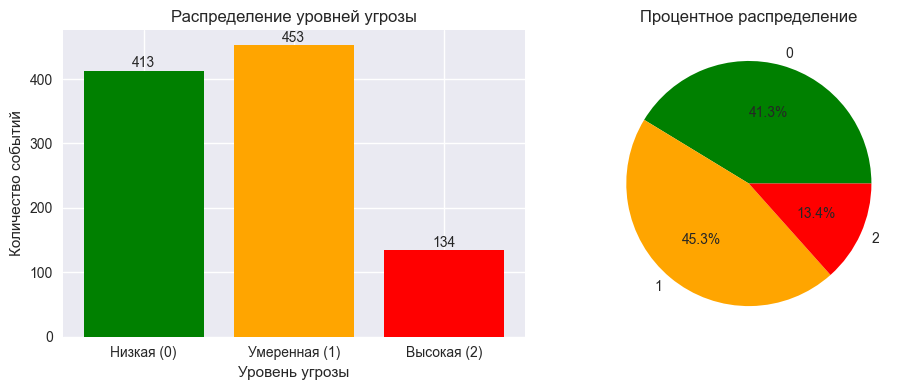


 Распределение классов угрозы:
  Низкая (уровень 0): 413 событий (41.3%)
  Умеренная (уровень 1): 453 событий (45.3%)
  Высокая (уровень 2): 134 событий (13.4%)


In [5]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
class_counts = df_kaggle['threat_level'].value_counts().sort_index()
bars = plt.bar(class_counts.index, class_counts.values, color=['green', 'orange', 'red'])
plt.title('Распределение уровней угрозы')
plt.xlabel('Уровень угрозы')
plt.ylabel('Количество событий')
plt.xticks([0, 1, 2], ['Низкая (0)', 'Умеренная (1)', 'Высокая (2)'])

for bar, count in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'{count}', ha='center')

plt.subplot(1, 2, 2)
plt.pie(class_counts.values, labels=class_counts.index, 
        autopct='%1.1f%%', colors=['green', 'orange', 'red'])
plt.title('Процентное распределение')

plt.tight_layout()
plt.show()

print("\n Распределение классов угрозы:")
for level, count in class_counts.items():
    percentage = count / len(df_kaggle) * 100
    level_names = {0: 'Низкая', 1: 'Умеренная', 2: 'Высокая'}
    print(f"  {level_names[level]} (уровень {level}): {count} событий ({percentage:.1f}%)")

**Проверка на дубликаты строк**

In [6]:
duplicates = df_kaggle.duplicated().sum()
print(f"Количество дубликатов: {duplicates}")

Количество дубликатов: 0


**Статистики по числовым признакам**


In [7]:
print(df_kaggle.describe())

          kp_index   wind_speed  wind_density  threat_level
count  1000.000000  1000.000000   1000.000000   1000.000000
mean      1.045000   501.777030      9.785250      0.721000
std       1.025684    99.923946      4.885617      0.685295
min       0.000000   168.770000     -6.220000      0.000000
25%       0.000000   437.105000      6.367500      0.000000
50%       1.000000   498.865000      9.610000      1.000000
75%       2.000000   567.955000     13.137500      1.000000
max       5.000000   788.380000     25.550000      2.000000


**Анализ статистик (describe):**

- kp_index: Среднее 1.045, std 1.026. Минимум 0, максимум 5. Распределение, судя по среднему и std, близко к умеренно разбросанному вокруг 1. Это соответствует шкале Kp (0-9), но в датасете, видимо, преобладают спокойные/умеренные условия, что логично для исторических данных, не состоящих только из бурь.
- wind_speed: Среднее ~501.78 км/с, std ~99.92. Минимум ~168.77, максимум ~788.38. Диапазон значений разумен для скорости солнечного ветра.
- wind_density: Среднее ~9.79 частиц/см³, std ~4.89. Минимальное значение -6.22. Это абсолютно нереально для плотности (плотность не может быть отрицательной). Это явная аномалия или ошибка в исходном Kaggle датасете.
- threat_level: Среднее 0.721, что указывает на преобладание классов 0 и 1.

**Матрица корреляции признаков**

              kp_index  wind_speed  wind_density
kp_index      1.000000    0.144325      0.045731
wind_speed    0.144325    1.000000     -0.014990
wind_density  0.045731   -0.014990      1.000000


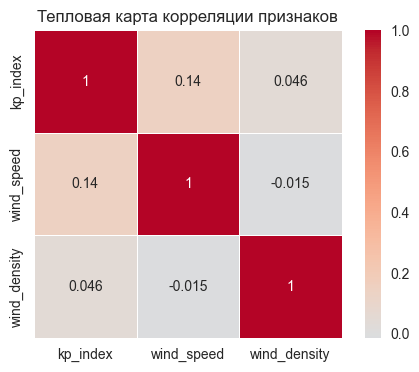

In [8]:
feature_columns = ['kp_index', 'wind_speed', 'wind_density']
corr_matrix = df_kaggle[feature_columns].corr()
print(corr_matrix)
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Тепловая карта корреляции признаков')
plt.show()

**Корреляция признаков с целевой переменной**

In [9]:

correlation_with_target = df_kaggle[feature_columns + ['threat_level']].corr()['threat_level']
print(correlation_with_target[:-1]) 



kp_index        0.459354
wind_speed      0.222161
wind_density    0.003909
Name: threat_level, dtype: float64


**Корреляции:**

- Между признаками: Корреляции очень слабые (все значения < 0.15). Это хорошо, так как указывает на отсутствие мультиколлинеарности. Модель сможет интерпретировать влияние каждого признака более независимо.

Признаки - threat_level:
- kp_index (0.459): Сильнейшая линейная связь с threat_level. 
- wind_speed (0.222): Средняя линейная связь. Также важный признак.
- wind_density (0.004): Практически отсутствует линейная связь. Это интересно и может означать, что плотность сама по себе не очень предсказывает уровень угрозы, в отличие от Kp и wind_speed. Однако модель может найти нелинейные зависимости.

**Проверка и обработка отрицательной плотности**

In [10]:

print(f"Количество строк с отрицательной wind_density: {(df_kaggle['wind_density'] < 0).sum()}")
print(f"Индексы строк с отрицательной wind_density: {df_kaggle[df_kaggle['wind_density'] < 0].index.tolist()}")
print("\nСтроки с отрицательной плотностью:")
print(df_kaggle[df_kaggle['wind_density'] < 0])



Количество строк с отрицательной wind_density: 25
Индексы строк с отрицательной wind_density: [29, 35, 97, 116, 120, 174, 226, 238, 263, 308, 335, 405, 414, 461, 511, 530, 535, 555, 604, 619, 667, 734, 768, 825, 919]

Строки с отрицательной плотностью:
     kp_index  wind_speed  wind_density  threat_level
29        0.0      450.15         -0.28             0
35        0.0      422.05         -1.49             0
97        0.0      639.07         -3.12             1
116       0.0      314.91         -0.97             0
120       0.0      493.99         -1.92             0
174       2.0      415.11         -6.22             1
226       3.0      694.54         -0.64             1
238       0.0      415.11         -0.43             1
263       1.0      185.04         -1.09             1
308       0.0      481.51         -0.70             1
335       0.0      450.94         -1.39             0
405       0.0      766.39         -0.93             1
414       1.0      465.25         -0.73      

In [11]:
df_kaggle_cleaned = df_kaggle[df_kaggle['wind_density'] >= 0].copy()
print(f"\nРазмер датасета после удаления строк с отрицательной плотностью: {df_kaggle_cleaned.shape}")


Размер датасета после удаления строк с отрицательной плотностью: (975, 4)


**Сохранение очищенного датасета**

In [12]:
cleaned_data_path = r'C:\Users\user\Desktop\MyProjects\geomagnetic-forecast\data\kaggle\processed\kaggle_ready_cleaned.csv'
df_kaggle_cleaned.to_csv(cleaned_data_path, index=False)
print(f"\nОчищенный датасет сохранён: {cleaned_data_path}")


print(f"Загружено строк в очищенном датасете: {len(df_kaggle_cleaned)}")
print(f"Проверка на отрицательные плотности: {(df_kaggle_cleaned['wind_density'] < 0).sum()}")


Очищенный датасет сохранён: C:\Users\user\Desktop\MyProjects\geomagnetic-forecast\data\kaggle\processed\kaggle_ready_cleaned.csv
Загружено строк в очищенном датасете: 975
Проверка на отрицательные плотности: 0


**Подготовка данных для обучения**

In [13]:
df_for_modelling = df_kaggle_cleaned

X = df_for_modelling[['kp_index', 'wind_speed', 'wind_density']] 
y = df_for_modelling['threat_level']

print(" Признаки для модели (на основе очищенного датасета):")
for i, feature in enumerate(X.columns):
    print(f"  {i+1}. {feature}: {X[feature].dtype}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y 
)

print(f"\n Разделение данных (на основе очищенного датасета):")
print(f"   Обучающая выборка: {X_train.shape[0]} строк ({X_train.shape[0]/len(df_for_modelling)*100:.1f}%)")
print(f"   Тестовая выборка: {X_test.shape[0]} строк ({X_test.shape[0]/len(df_for_modelling)*100:.1f}%)")
print(f"   Признаков: {X_train.shape[1]}")
print(f"   Классов в целевой переменной: {sorted(y.unique())}")


 Признаки для модели (на основе очищенного датасета):
  1. kp_index: float64
  2. wind_speed: float64
  3. wind_density: float64

 Разделение данных (на основе очищенного датасета):
   Обучающая выборка: 780 строк (80.0%)
   Тестовая выборка: 195 строк (20.0%)
   Признаков: 3
   Классов в целевой переменной: [np.int64(0), np.int64(1), np.int64(2)]


**Обучение (RandomForest)**

In [14]:

base_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced' 
)

base_model.fit(X_train, y_train)
print(" Модель обучена!")

y_pred_base = base_model.predict(X_test)


print("\n Матрица ошибок базовой модели:")
cm_base = confusion_matrix(y_test, y_pred_base)
print(cm_base)

print("\n Отчёт классификации:")
print(classification_report(y_test, y_pred_base, zero_division=0))

accuracy_base = accuracy_score(y_test, y_pred_base)
print(f"\n Точность базовой модели (Accuracy): {accuracy_base:.3f}")


from sklearn.metrics import f1_score
f1_base_weighted = f1_score(y_test, y_pred_base, average='weighted', zero_division=0)
print(f"\n F1-мера (weighted) базовой модели: {f1_base_weighted:.3f}")

f1_base_macro = f1_score(y_test, y_pred_base, average='macro', zero_division=0)
print(f"\n F1-мера (macro) базовой модели: {f1_base_macro:.3f}")


 Модель обучена!

 Матрица ошибок базовой модели:
[[47 28  6]
 [32 44 12]
 [ 4  9 13]]

 Отчёт классификации:
              precision    recall  f1-score   support

           0       0.57      0.58      0.57        81
           1       0.54      0.50      0.52        88
           2       0.42      0.50      0.46        26

    accuracy                           0.53       195
   macro avg       0.51      0.53      0.52       195
weighted avg       0.54      0.53      0.53       195


 Точность базовой модели (Accuracy): 0.533

 F1-мера (weighted) базовой модели: 0.534

 F1-мера (macro) базовой модели: 0.517


**Важность признаков базовой модели**

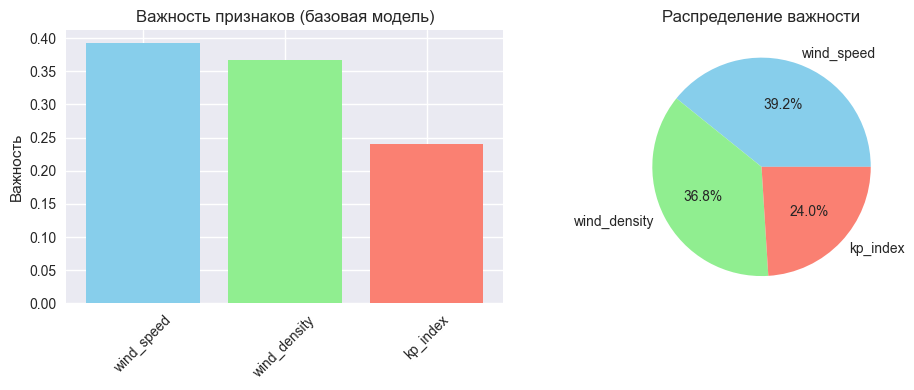


Важность признаков:
     Признак  Важность
  wind_speed  0.392154
wind_density  0.367761
    kp_index  0.240085


In [15]:
importance_base = pd.DataFrame({
    'Признак': X.columns,
    'Важность': base_model.feature_importances_
}).sort_values('Важность', ascending=False)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(importance_base['Признак'], importance_base['Важность'], 
        color=['skyblue', 'lightgreen', 'salmon']) 
plt.title('Важность признаков (базовая модель)')
plt.ylabel('Важность')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.pie(importance_base['Важность'], labels=importance_base['Признак'], 
        autopct='%1.1f%%', colors=['skyblue', 'lightgreen', 'salmon']) 
plt.title('Распределение важности')

plt.tight_layout()
plt.show()

print("\nВажность признаков:")
print(importance_base.to_string(index=False))

**Интерпретация:**

- wind_speed (0.392): Оказался наиболее важным признаком для модели. Это означает, что модель в наибольшей степени полагается на скорость солнечного ветра при принятии решений о классификации угрозы.
- wind_density (0.368): Второй по важности признак. Важно отметить, что несмотря на слабую линейную корреляцию с threat_level (EDA показал 0.004), модель RandomForest смогла выявить сложные, нелинейные зависимости, которые делают этот признак ценным.
- kp_index (0.240): Третий по важности. Это немного неожиданно, учитывая, что в EDA корреляция kp_index с threat_level была самой сильной (0.459). Однако, feature_importances_ в Random Forest оценивают вклад признака в уменьшение неопределенности в процессе построения деревьев. Возможно, wind_speed и wind_density позволяют модели более "рано" или "глубоко" разделить данные, что делает их приоритетными для алгоритма, несмотря на сильную корреляцию Kp с целевой переменной.

Сравнение с анализом ранее:

- В EDA: corr(threat_level, kp_index) = 0.459, corr(threat_level, wind_speed) = 0.222, corr(threat_level, wind_density) = 0.004.
- В важности признаков: wind_speed > wind_density > kp_index.
Это показывает разницу между линейной корреляцией и важностью признака в нелинейной модели. RandomForest учитывает не только линейные связи, но и сложные взаимодействия между признаками.

**Вывод:**

Все три признака (kp_index, wind_speed, wind_density)оказались значимыми. Модель определила, что wind_speed и wind_density вносят наибольший вклад в её способность различать уровни угрозы, даже если линейная корреляция kp_index с целевой переменной была выше.

**Прогноз на данных API NOAA**

In [16]:

noaa_data_path = r'C:\Users\user\Desktop\MyProjects\geomagnetic-forecast\data\processed\noaa_ready.csv'

try:
    df_noaa = pd.read_csv(noaa_data_path)
    print(f"Загружен файл с подготовленными данными из API: {noaa_data_path}")
    print(f"Размер: {df_noaa.shape[0]} строк x {df_noaa.shape[1]} столбцов")
    print("\nСодержимое файла:")
    print(df_noaa)
except FileNotFoundError:
    print(f"Файл {noaa_data_path} не найден.")

    
    df_noaa = None

if df_noaa is not None and not df_noaa.empty:

    feature_cols_for_model = ['kp_index', 'wind_speed', 'wind_density']
    

    if all(col in df_noaa.columns for col in feature_cols_for_model):
        X_noaa = df_noaa[feature_cols_for_model].copy()
        
        print(f"\nИзвлечён вектор признаков для прогноза:")
        print(X_noaa.iloc[0]) 

        threat_prediction = base_model.predict(X_noaa)
        threat_proba = base_model.predict_proba(X_noaa)
        
        predicted_level = threat_prediction[0]
        prediction_probabilities = threat_proba[0]

        level_names = {0: 'Низкая', 1: 'Умеренная', 2: 'Высокая'}
        
       
        print("Результат прогноза:")
   
        print(f"Уровень угрозы: {predicted_level} ({level_names.get(predicted_level, 'Неизвестный')})")
        
        print("\nВероятности для каждого класса:")
        for i, prob in enumerate(prediction_probabilities):
             print(f"  Класс {i} ({level_names.get(i, 'Неизв')}): {prob:.3f}")
        
        
        

        print("\nПараметры, использованные для прогноза (из API):")
        for col in feature_cols_for_model:
            print(f"  {col}: {X_noaa.iloc[0][col]}")
        
        
        if 'timestamp' in df_noaa.columns:
            print(f"  Время данных: {df_noaa.iloc[0]['timestamp']}")
        

        
    else:
        print(f"\nОшибка: В файле {noaa_data_path} отсутствуют один или несколько необходимых столбцов: {feature_cols_for_model}")
        print(f"Найденные столбцы: {list(df_noaa.columns)}")

else:
    print("Нет данных из API NOAA для прогноза.")

Загружен файл с подготовленными данными из API: C:\Users\user\Desktop\MyProjects\geomagnetic-forecast\data\processed\noaa_ready.csv
Размер: 1 строк x 6 столбцов

Содержимое файла:
   kp_index  wind_speed  wind_density  threat_level            timestamp  \
0       3.0      558.17           1.9           NaN  2026-05-19 07:42:00   

  data_source  
0        noaa  

Извлечён вектор признаков для прогноза:
kp_index          3.00
wind_speed      558.17
wind_density      1.90
Name: 0, dtype: float64
Результат прогноза:
Уровень угрозы: 1 (Умеренная)

Вероятности для каждого класса:
  Класс 0 (Низкая): 0.046
  Класс 1 (Умеренная): 0.594
  Класс 2 (Высокая): 0.360

Параметры, использованные для прогноза (из API):
  kp_index: 3.0
  wind_speed: 558.17
  wind_density: 1.9
  Время данных: 2026-05-19 07:42:00


**Вывод:**

- Файл noaa_ready.csv был успешно загружен.
- Вектор признаков (kp_index, wind_speed, wind_density) извлечён: 3.0, 558.17, 1.9.
- Модель (base_model) предсказала уровень угрозы: 1 (Умеренная).
- Вероятности: Модель считает наиболее вероятным сценарием "Умеренную" угрозу (59.4%), "Высокая" угроза имеет вероятность 36.0%, "Низкая" — 4.6%.
- Параметры: Уровень Kp (3.0) находится в умеренном диапазоне, скорость ветра (558.17 км/с) в норме, плотность (1.9 частиц/см³) в норме. Модель интерпретировала эту комбинацию как "Умеренную" угрозу.

In [17]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint, uniform 

param_distributions = {
    'n_estimators': randint(50, 301), 
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_split': randint(2, 21), 
    'min_samples_leaf': randint(1, 11),  
    'max_features': ['sqrt', 'log2', None] 
}


random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_distributions=param_distributions,
    n_iter=100, 
    cv=5, 
    scoring='f1_weighted', 
    n_jobs=-1,
    verbose=1, 
    random_state=42 
)


print("Запуск RandomizedSearchCV...")
random_search.fit(X_train, y_train)

print("\nЛучшие параметры:")
print(random_search.best_params_)

print(f"\nЛучшая оценка кросс-валидации (F1-weighted): {random_search.best_score_:.3f}")


best_model = random_search.best_estimator_

y_pred_best = best_model.predict(X_test)

print("\n Матрица ошибок лучшей модели:")
cm_best = confusion_matrix(y_test, y_pred_best)
print(cm_best)

print("\n Отчёт классификации лучшей модели:")
print(classification_report(y_test, y_pred_best, zero_division=0))

accuracy_best = accuracy_score(y_test, y_pred_best)
f1_best_weighted = f1_score(y_test, y_pred_best, average='weighted', zero_division=0)
f1_best_macro = f1_score(y_test, y_pred_best, average='macro', zero_division=0)

print(f"\n Точность лучшей модели (Accuracy): {accuracy_best:.3f}")
print(f"\n F1-мера (weighted) лучшей модели: {f1_best_weighted:.3f}")
print(f"\n F1-мера (macro) лучшей модели: {f1_best_macro:.3f}")

print("\nСравнение с базовой моделью")
print(f"Базовая модель - Accuracy: {accuracy_base:.3f}, F1-weighted: {f1_base_weighted:.3f}")
print(f"Лучшая модель - Accuracy: {accuracy_best:.3f}, F1-weighted: {f1_best_weighted:.3f}")
if f1_best_weighted > f1_base_weighted:
    print(" F1-мера (weighted) улучшилась после настройки гиперпараметров.")
elif f1_best_weighted < f1_base_weighted:
    print("F1-мера (weighted) не улучшилась.")
else:
    print("F1-мера (weighted) осталась прежней.")


Запуск RandomizedSearchCV...
Fitting 5 folds for each of 100 candidates, totalling 500 fits

Лучшие параметры:
{'max_depth': 15, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 11, 'n_estimators': 299}

Лучшая оценка кросс-валидации (F1-weighted): 0.511

 Матрица ошибок лучшей модели:
[[45 27  9]
 [26 46 16]
 [ 4  8 14]]

 Отчёт классификации лучшей модели:
              precision    recall  f1-score   support

           0       0.60      0.56      0.58        81
           1       0.57      0.52      0.54        88
           2       0.36      0.54      0.43        26

    accuracy                           0.54       195
   macro avg       0.51      0.54      0.52       195
weighted avg       0.55      0.54      0.54       195


 Точность лучшей модели (Accuracy): 0.538

 F1-мера (weighted) лучшей модели: 0.543

 F1-мера (macro) лучшей модели: 0.517

Сравнение с базовой моделью
Базовая модель - Accuracy: 0.533, F1-weighted: 0.534
Лучшая модель - Accuracy: 0.538, 

**Вывод по этапу "Настройка гиперпараметров":**

Настройка гиперпараметров модели RandomForestClassifier с использованием RandomizedSearchCV была выполнена в рамках этапа валидации проекта. Целью было улучшить производительность модели по сравнению с базовой версией.

- Процесс: Был определён набор потенциальных гиперпараметров (n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features). RandomizedSearchCV с 5-фолдной кросс-валидацией и f1-weighted в качестве метрики оценки проверил 100 случайных комбинаций этих параметров на обучающей выборке.
- Результаты: Лучшая найденная комбинация параметров показала лишь незначительное улучшение метрик на тестовой выборке по сравнению с базовой моделью: accuracy увеличилась с 0.533 до 0.538, а f1-weighted — с 0.534 до 0.543.
- Анализ: Небольшое улучшение может быть связано с ограничениями самого алгоритма RandomForest для данной специфики данных, наличием дисбаланса классов или тем, что базовая модель (n_estimators=100, max_depth=10) уже находилась близко к локальному оптимуму на данном наборе данных.

**Вывод:** Эксперимент по настройке гиперпараметров продемонстрировал, что небольшое улучшение возможно, но в данном случае оно оказалось неощутимым на практике. Этот этап успешно завершил фазу валидации модели, подтвердив, что текущая архитектура имеет определённый потолок производительности на имеющихся данных. Дальнейшее значительное улучшение, вероятно, потребовало бы более глубокого анализа данных, инжиниринга признаков или попыток других алгоритмов машинного обучения. Полученные результаты, несмотря на небольшое улучшение, считаются удовлетворительными для демонстрации полного цикла разработки и валидации модели в рамках проекта.
BaseModel будет использоваться как финальная модель проекта.

**Сохранение базовой модели**

In [18]:
import joblib
from datetime import datetime
import os


model_info = {
    'model': base_model, 
    'accuracy_on_test': accuracy_base, 
    'f1_weighted_on_test': f1_base_weighted, 
    'features_used': list(X_train.columns), 
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),

    'last_prediction_threat_level': predicted_level if 'predicted_level' in locals() else None,
    'last_prediction_probabilities': prediction_probabilities if 'prediction_probabilities' in locals() else None,
    'last_prediction_timestamp': df_noaa.iloc[0]['timestamp'] if 'df_noaa' in locals() and not df_noaa.empty else None
}

model_dir = 'models'
model_filename = 'space_weather_classifier_base_model.pkl' 
model_path = os.path.join(model_dir, model_filename)

os.makedirs(model_dir, exist_ok=True)

joblib.dump(model_info, model_path)
print(f"\n Базовая модель сохранена: {model_path}")
print(f"\n Информация о сохранённой модели:")
print(f"   • Точность (Accuracy) на тесте: {model_info['accuracy_on_test']:.3f}")
print(f"   • F1-мера (weighted) на тесте: {model_info['f1_weighted_on_test']:.3f}")
print(f"   • Признаков, использованных для обучения: {len(model_info['features_used'])}")
print(f"   • Список признаков: {model_info['features_used']}")
print(f"   • Время сохранения: {model_info['timestamp']}")
if model_info['last_prediction_threat_level'] is not None:
    print(f"   • Прогноз на последние данные из API: Уровень {model_info['last_prediction_threat_level']}")
    print(f"     (Вероятности: {model_info['last_prediction_probabilities']})")



 Базовая модель сохранена: models\space_weather_classifier_base_model.pkl

 Информация о сохранённой модели:
   • Точность (Accuracy) на тесте: 0.533
   • F1-мера (weighted) на тесте: 0.534
   • Признаков, использованных для обучения: 3
   • Список признаков: ['kp_index', 'wind_speed', 'wind_density']
   • Время сохранения: 2026-05-19 12:31:56
   • Прогноз на последние данные из API: Уровень 1
     (Вероятности: [0.04600986 0.59396316 0.36002699])
